# TRIAD Map Structure

Visualizes the canonical map defined in `src/triad/map_data.py`: a rotationally
symmetric 3-player Diplomacy variant (16 provinces, 30 edges, 12 supply
centers). The layout is built by placing power **A**'s provinces and rotating
them by C3 (`ROTATION`, A→B→C) so the exact rotational symmetry of the map is
visible in the figure itself.

**Legend cues:** node color = owning power (home SCs) or gray (neutral);
squares = supply centers, circles = non-SC provinces; a black ring marks each
power's capital; the dashed hub is `CTR`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Import the single source of truth for the map (triad is installed editable
# by `uv sync`; select the project venv as the notebook kernel).
from triad import map_data as md

print(f"{len(md.PROVINCES)} provinces, {len(md.SUPPLY_CENTERS)} supply centers")
n_edges = sum(len(v) for v in md.ADJACENCY.values()) // 2
print(f"{n_edges} undirected edges")

16 provinces, 12 supply centers
30 undirected edges


In [2]:
# Build 2D coordinates that expose the C3 symmetry.
#
# Place power A's provinces (plus the two structures A "owns" a copy of: the
# B_AB border and the CTR hub), then generate B and C by rotating each point
# 120 deg / 240 deg and relabeling via ROTATION (A->B->C). Because ROTATION is
# a graph automorphism, edges come out symmetric for free.

MIRROR = True  # reflect the whole layout across the vertical axis (x -> -x)

def polar(deg, r):
    a = np.deg2rad(deg)
    return np.array([r * np.cos(a), r * np.sin(a)])

def rotate(p, deg):
    a = np.deg2rad(deg)
    c, s = np.cos(a), np.sin(a)
    return np.array([c * p[0] - s * p[1], s * p[0] + c * p[1]])

# Power A sits at the top (90 deg); B and C follow clockwise at -120 deg steps.
base = {
    "CTR":    polar(90, 0.0),
    "GATE_A": polar(90, 1.3),
    "CAP_A":  polar(90, 3.5),
    "L_A":    polar(113, 3.3),
    "R_A":    polar(67, 3.3),
    "B_AB":   polar(30, 1.8),
}

POS = {}
for node, xy in base.items():
    POS[node] = xy
    n1 = md.ROTATION[node]
    POS[n1] = rotate(xy, -120)
    n2 = md.ROTATION[n1]
    POS[n2] = rotate(xy, -240)

# Mirror is a graph automorphism of the drawing (it only flips x), so it leaves
# the map's structure intact while swapping the visual handedness: with MIRROR
# the cycle A->B->C reads counter-clockwise and each power's L/R flanks swap sides.
if MIRROR:
    POS = {p: np.array([-x, y]) for p, (x, y) in POS.items()}

assert set(POS) == set(md.PROVINCES), "every province must have a position"

In [3]:
# Classify each province for styling.
POWER_COLORS = {"A": "#d62728", "B": "#1f77b4", "C": "#2ca02c"}
NEUTRAL_COLOR = "#9e9e9e"

# Map each home province back to its owning power.
owner = {}
for power, homes in md.HOME_CENTERS.items():
    for prov in homes:
        owner[prov] = power

def node_color(prov):
    return POWER_COLORS.get(owner.get(prov), NEUTRAL_COLOR)

sc_set = set(md.SUPPLY_CENTERS)
caps = {"CAP_A", "CAP_B", "CAP_C"}

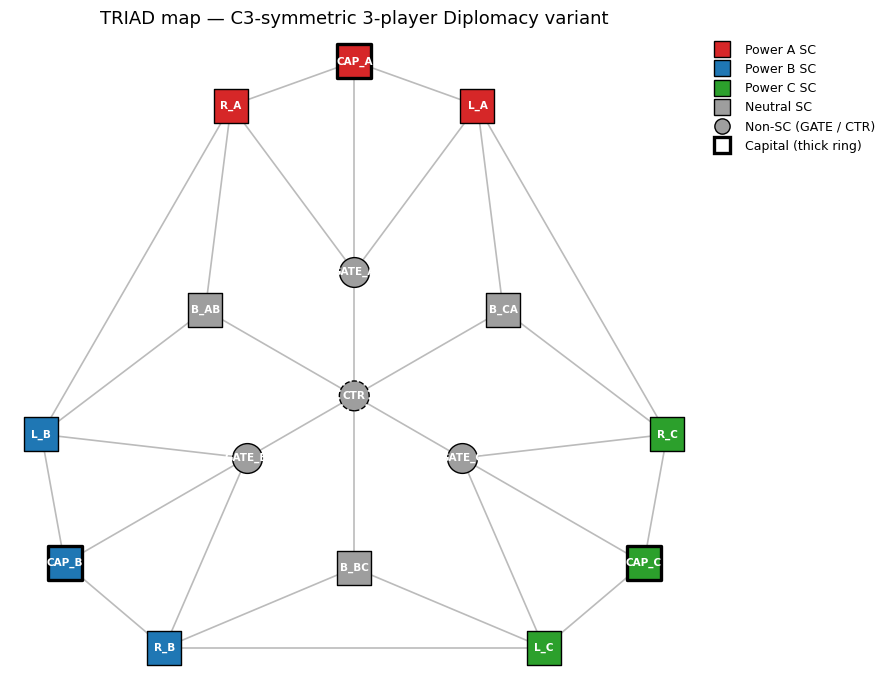

In [4]:
fig, ax = plt.subplots(figsize=(9, 9))
ax.set_aspect("equal")
ax.axis("off")

# --- edges (undirected, drawn once) ---
seen = set()
for a, nbrs in md.ADJACENCY.items():
    for b in nbrs:
        key = tuple(sorted((a, b)))
        if key in seen:
            continue
        seen.add(key)
        (x0, y0), (x1, y1) = POS[a], POS[b]
        ax.plot([x0, x1], [y0, y1], color="#bbbbbb", lw=1.2, zorder=1)

# --- nodes ---
for prov, (x, y) in POS.items():
    is_sc = prov in sc_set
    is_ctr = prov == "CTR"
    ax.scatter(
        x, y,
        s=620 if is_sc else 460,
        marker="s" if is_sc else "o",
        c=node_color(prov),
        edgecolors="black",
        linewidths=2.4 if prov in caps else 1.0,
        linestyle="--" if is_ctr else "-",
        zorder=2,
    )
    ax.text(
        x, y, prov, ha="center", va="center",
        fontsize=7.5, fontweight="bold", color="white", zorder=3,
    )

# --- legend ---
from matplotlib.lines import Line2D
legend_items = [
    Line2D([0], [0], marker="s", color="w", markerfacecolor=POWER_COLORS["A"],
           markeredgecolor="k", markersize=12, label="Power A SC"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=POWER_COLORS["B"],
           markeredgecolor="k", markersize=12, label="Power B SC"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=POWER_COLORS["C"],
           markeredgecolor="k", markersize=12, label="Power C SC"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=NEUTRAL_COLOR,
           markeredgecolor="k", markersize=12, label="Neutral SC"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=NEUTRAL_COLOR,
           markeredgecolor="k", markersize=11, label="Non-SC (GATE / CTR)"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="w",
           markeredgecolor="k", markeredgewidth=2.4, markersize=12,
           label="Capital (thick ring)"),
]
ax.legend(handles=legend_items, loc="upper left", bbox_to_anchor=(1.0, 1.0),
          frameon=False, fontsize=9)

ax.set_title("TRIAD map — C3-symmetric 3-player Diplomacy variant", fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
# Structural summary: degree distribution should be 12 nodes of deg 3,
# 3 gates of deg 4, and CTR of deg 6 (per the map spec).
from collections import Counter

degrees = {p: len(nbrs) for p, nbrs in md.ADJACENCY.items()}
dist = Counter(degrees.values())
print("degree : count of provinces")
for deg in sorted(dist):
    provs = sorted(p for p, d in degrees.items() if d == deg)
    print(f"   {deg}   :  {dist[deg]:>2}   {provs}")

degree : count of provinces
   3   :   6   ['B_AB', 'B_BC', 'B_CA', 'CAP_A', 'CAP_B', 'CAP_C']
   4   :   9   ['GATE_A', 'GATE_B', 'GATE_C', 'L_A', 'L_B', 'L_C', 'R_A', 'R_B', 'R_C']
   6   :   1   ['CTR']
